In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Mencoba tema seaborn clean
sns.set_theme(style="white", palette="deep")


In [ ]:


df = pd.read_csv('../Training_Data I.csv')

df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            str    
 2   amount          float64
 3   nameOrig        str    
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        str    
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), str(3)
memory usage: 534.0 MB


In [4]:
df.dtypes

step                int64
type                  str
amount            float64
nameOrig              str
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest              str
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
isFlaggedFraud      int64
dtype: object

In [5]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='str')

In [6]:
print("Jumlah missing values: ")
print(df.isnull().sum())

print("\n-------------------------------------------------------\n")

print("Jumlah data duplikat: ")
print(df.duplicated().sum())

Jumlah missing values: 
step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

-------------------------------------------------------

Jumlah data duplikat: 
0


In [7]:
df.describe().round(2)

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6362620.00,6362620.00,6362620.00,6362620.00,6.362620e+06,6.362620e+06,6362620.00,6362620.0
mean,243.40,179861.90,833883.10,855113.67,1.100702e+06,1.224996e+06,0.00,0.0
std,142.33,603858.23,2888242.67,2924048.50,3.399180e+06,3.674129e+06,0.04,0.0
min,1.00,0.00,0.00,0.00,0.000000e+00,0.000000e+00,0.00,0.0
25%,156.00,13389.57,0.00,0.00,0.000000e+00,0.000000e+00,0.00,0.0
50%,239.00,74871.94,14208.00,0.00,1.327057e+05,2.146614e+05,0.00,0.0
75%,335.00,208721.48,107315.18,144258.41,9.430367e+05,1.111909e+06,0.00,0.0
max,743.00,92445516.64,59585040.37,49585040.37,3.560159e+08,3.561793e+08,1.00,1.0


In [8]:
print("Jumlah transaksi: ")
print(df['isFraud'].value_counts())

print("\n-------------------------------------------\n")

print("Presentase (%): ")
print((df['isFraud'].value_counts(normalize=True)*100).round(3))

Jumlah transaksi: 
isFraud
0    6354407
1       8213
Name: count, dtype: int64

-------------------------------------------

Presentase (%): 
isFraud
0    99.871
1     0.129
Name: proportion, dtype: float64


In [9]:
#menampilkan transaksi terbesar
transaksi_terbesasr = df[df['amount'] == df['amount'].max()]
transaksi_terbesasr

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
3686583,276,TRANSFER,92445516.64,C1715283297,0.0,0.0,C439737079,9595.98,92455112.62,0,0


# Validasi 0.129%

In [10]:
#Memfilter data yang terbukti Fraud
data_fraud = df[df['isFraud'] == 1]

#Melihat type dari transaksi
print("Tipe transaksi fraud: ")
print(data_fraud['type'].value_counts())

print("\n------------------------------\n")

#Melihat data statistik khusus Fraud
print("Statistik nominal (amount) khusus transaksi fraud: ")
print(data_fraud['amount'].describe().round(2))

Tipe transaksi fraud: 
type
CASH_OUT    4116
TRANSFER    4097
Name: count, dtype: int64

------------------------------

Statistik nominal (amount) khusus transaksi fraud: 
count        8213.00
mean      1467967.30
std       2404252.95
min             0.00
25%        127091.33
50%        441423.44
75%       1517771.48
max      10000000.00
Name: amount, dtype: float64


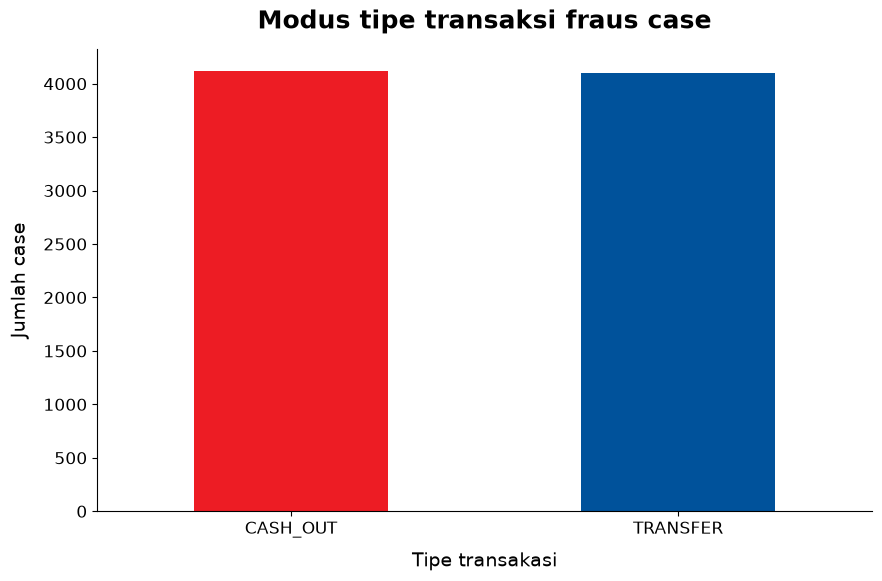

In [18]:
red = '#ed1c24'
blue = '#00529b'

# Rasio kanvas
plt.figure(figsize=(10,6))

# Membuat bar chart
data_fraud['type'].value_counts().plot(kind='bar', color=[red, blue])

plt.title('Modus tipe transaksi fraus case', fontsize=18, fontweight='bold', pad=15)
plt.xlabel('Tipe transakasi', fontsize=14, labelpad=10)
plt.ylabel('Jumlah case', fontsize=14, labelpad=10)
plt.xticks(rotation=0, fontsize=12)
plt.yticks(fontsize=12)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.show()


In [19]:
# Ambil data fraud
df_fraud = data_fraud.copy()

# Pengecekan sistem, jika hasilnya 0 maka sistem baik
df_fraud['kebocoran_sistem'] = df_fraud['newbalanceOrig'] - (df_fraud['oldbalanceOrg'] - df_fraud['amount'])

# 3. Menampilkan ringkasan statistik dari kebocoran 
print("Statistik Kebocoran Sistem pada Transaksi Fraud:")
print(df_fraud['kebocoran_sistem'].describe().round(2))

Statistik Kebocoran Sistem pada Transaksi Fraud:
count        8213.00
mean        10692.33
std        265146.13
min            -0.00
25%             0.00
50%             0.00
75%             0.00
max      10000000.00
Name: kebocoran_sistem, dtype: float64
